# Figure 3: Dynamic Spectral Features

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mne.baseline import rescale
from mne.time_frequency import tfr_array_multitaper

from neurodsp.spectral import compute_spectrum
from neurodsp.sim import sim_synaptic_current, sim_combined, sim_knee
from neurodsp.utils import create_times, set_random_seed
from neurodsp.filt import filter_signal
from neurodsp.plts import plot_time_series

from fooof.plts import plot_spectra
from fooof.utils import trim_spectrum

/var/folders/59/8y2d5r257c77vzymnqs47x080000gn/T/ipykernel_31652/1045837735.py:13: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof.plts import plot_spectra


In [2]:
set_random_seed(505)

In [3]:
import seaborn as sns
sns.set_context('talk')

## Settings

In [4]:
# Sim settings
fs = 500
n_seconds = 2

knee_freq = 50   
exp = -1.9

In [5]:
# Create a times vector
times = create_times(n_seconds * 2, fs)

In [6]:
# Set which function to use to compute the spectrogram
spect_func = tfr_array_multitaper

In [7]:
# Settings for computing power spectra
nperseg = fs
f_range = [1, 150]

In [8]:
# Settings for computing spectrogram
freqs = np.arange(1, 150, 0.25)
n_cycles = freqs / 1.5

In [9]:
# Plot settings
cmap = 'RdBu_r'

## Simulate Time Series

In [10]:
# Define and collect simulation parameters
components1 = comps = {'sim_knee' : {'exponent1' : -0.25, 'exponent2' : -2.5, 'knee' : knee_freq**2}, 
                       'sim_bursty_oscillation' : [{'freq' : 23}, {'freq' : 24}, {'freq' : 24.5}, 
                                                   {'freq' : 25}, {'freq' : 25.5,}, 
                                                   {'freq' : 26,}, {'freq' : 27,}]
                      }
comp_vars = [1, 0.5, 0.5, 0.75, 1., 0.75, 0.5, 0.5]

In [11]:
# Simulate signal components and combine
sig1 = sim_combined(n_seconds, fs, components1, comp_vars)
sig2 = sim_knee(n_seconds, fs, -0.1, exp, knee_freq**2)
example_sig = np.concatenate((sig1, sig2))

In [12]:
# Filter signal
example_sig = filter_signal(example_sig, fs, 'lowpass', 150, remove_edges=False)

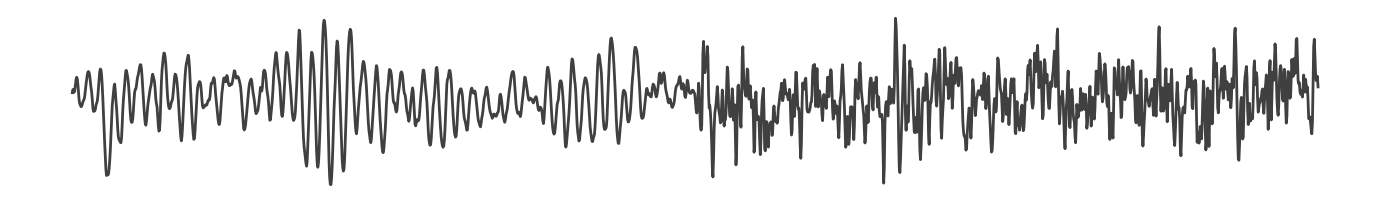

In [13]:
# Plot the time series
plot_time_series(times, example_sig, lw=2, alpha=0.75, axis=False)

## Create Spectrogram

In [14]:
# Collect together a collection of simulations
sig0s, sig1s, sig2s = [], [], []
sims = []
n_sims = 100
for ind in range(n_sims):
    sig0 = sim_knee(1, fs, -0.25, -2.5, knee_freq**2)
    sig1 = sim_combined(n_seconds, fs, components1, comp_vars)
    sig2 = sim_knee(n_seconds, fs, -0.1, exp, knee_freq**2)

    sig0s.append(sig0)
    sig1s.append(sig1)
    sig2s.append(sig2)
    
    comb = np.array([])
    for temp in [sig0, sig1, sig2]:
        comb = np.concatenate((comb, temp))
    comb = filter_signal(comb, fs, 'lowpass', 150, remove_edges=False)    
    sims.append(comb)
    
sims = np.array(sims)

In [15]:
# Compute the spectrum
spect = spect_func(sims.reshape([1, *sims.shape]), fs, freqs=freqs,
                       n_cycles=n_cycles, output='power')
spect = np.squeeze(spect)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.5s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    1.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   24.3s finished


In [16]:
# Define times vector for the spectrogram
times = create_times(n_seconds*2 + 1, fs)

# Normalize the spectrogram data 
scaled_spect = rescale(spect, times, [0.25, 0.75], 'percent')

Applying baseline correction (mode: percent)


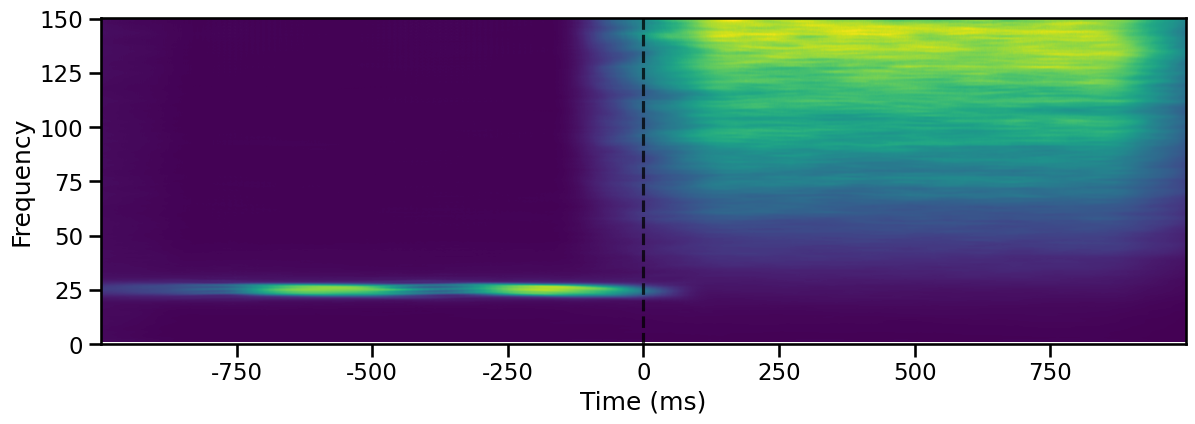

In [17]:
# Plot the spectrogram
_, ax = plt.subplots(figsize=(14, 10))
ax.imshow(np.flipud(np.mean(scaled_spect, 0)[:, 500:]))
ax.axvline(x=1000, color='black', alpha=0.75, linestyle='--')
ax.set_xticks([250, 500, 750, 1000, 1250, 1500, 1750],
              [-750, -500, -250, 0, 250, 500, 750]);
ax.set_yticks([0, 100, 200, 300, 400, 500, 600],
              ['150', '125', '100', '75', '50', '25', '0']);
ax.set(xlabel='Time (ms)', ylabel='Frequency');

## Create Power Spectra

In [18]:
# Compute the power spectra for the pre & post segments
freqs = trim_spectrum(*compute_spectrum(sig1s[0], fs, nperseg=nperseg), f_range)[0]
psds1 = [trim_spectrum(*compute_spectrum(sig, fs, nperseg=nperseg), f_range)[1] for sig in sig1s]
psds2 = [trim_spectrum(*compute_spectrum(sig, fs, nperseg=nperseg), f_range)[1] for sig in sig2s]

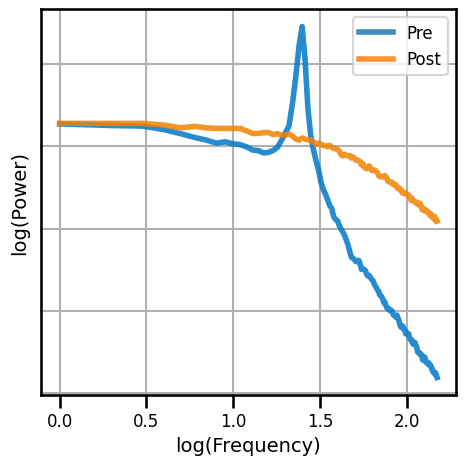

In [19]:
# Plot the power spectra for the pre & post segments
_, ax = plt.subplots(figsize=(5, 5))
plot_spectra(freqs, [np.mean(psds1, 0), np.mean(psds2, 0)], lw=4, alpha=0.85,
             log_freqs=True, log_powers=True, labels=['Pre', 'Post'], ax=ax)
plt.gca().yaxis.set_tick_params(length=1)
plt.gca().set_yticklabels([]);
plt.legend(loc=0, prop={'size': 12})
colors = ['#0077c7', '#f28100']
for line, color in zip(plt.gca().get_lines(), colors):
    line.set_color(color)